In [1]:
import math
import json
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import List, Dict
# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[1] / "src"))

from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.riczne import RichardsonZne
from nbutils.lsf_zne_hill import *
from nbutils.data_loader import load_all_experiments

from nbutils.lsf_zne import *

In [2]:
plt.rcParams.update({
    "font.family": "serif",
    #"font.serif": "Computer Modern Roman",
    "font.size": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,
})

---

### Load experimental data

In [3]:
# ==========================================
# Recursive experiment loader
# ==========================================

def load_all_experiments(data_root):
    """
    Recursively load all experiments under data_root and
    populate a master data_records dictionary.

    Parameters
    ----------
    data_root : str or Path
        Root directory containing experiment folders (e.g. data/)

    Returns
    -------
    data_records : dict
        Master experiment registry
    """
    data_root = Path(data_root)
    data_records = {}

    # Iterate over subdirectories like c0, c0.01, ...
    for exp_dir in sorted(p for p in data_root.iterdir() if p.is_dir()):
        experiment_id = exp_dir.name

        json_files = sorted(exp_dir.rglob("iter_*.json"))
        if not json_files:
            continue  # skip empty folders

        # --------------------------
        # Load and group raw data
        # --------------------------
        raw_groups = {}
        exact_solution = None

        for jf in json_files:
            with open(jf, "r") as f:
                data = json.load(f)

            t_max = data["config"]["ansatz"]["ugate"]["time"]["max"]
            cost = data["output"]["optimized_minimum_cost"][0]

            if exact_solution is None:
                exact_solution = data["output"].get("exact_sol", None)

            raw_groups.setdefault(t_max, []).append(cost)

        # --------------------------
        # Processed arrays
        # --------------------------
        t_vals = np.array(sorted(raw_groups.keys()))
        vqe_means = np.array([np.mean(raw_groups[t]) for t in t_vals])
        vqe_stds = np.array([np.std(raw_groups[t]) for t in t_vals])

        # --------------------------
        # Register experiment
        # --------------------------
        data_records[experiment_id] = {
            "meta": {
                "experiment_id": experiment_id,
                "data_path": str(exp_dir),
                "num_json_files": len(json_files),
                "noise_level": float(experiment_id.replace("c", "")) if experiment_id.startswith("c") else None,
            },

            "raw": {
                "json_files": [str(f) for f in json_files],
                "grouped_costs": raw_groups,
            },

            "processed": {
                "t_max": t_vals,
                "vqe_means": vqe_means,
                "vqe_stds": vqe_stds,
                "exact_solution": exact_solution,
            },

        }

    return data_records

In [4]:
data_records = load_all_experiments("data")

In [5]:
# ==========================================
# DATA EXTRACTION
# ==========================================
data_dir = Path("data/c0")
json_files = sorted(data_dir.rglob("iter_*.json"))

raw_groups, exact_sol = {}, None
for f in json_files:
    with open(f, "r") as file:
        data = json.load(file)
        big_t = data["config"]["ansatz"]["ugate"]["time"]["max"]
        cost = data["output"]["optimized_minimum_cost"][0]
        #if exact_sol is None: exact_sol = data["output"]["exact_sol"]
        if big_t not in raw_groups: raw_groups[big_t] = []
        raw_groups[big_t].append(cost)

EXPERIMENTAL_PROCESSED_DATA = [[(np.mean(raw_groups[t]), np.std(raw_groups[t])), t] for t in sorted(raw_groups.keys())]
print(f"Len: {len(EXPERIMENTAL_PROCESSED_DATA)}")
print(f"Extracted data for {EXPERIMENTAL_PROCESSED_DATA} noise levels.")

Len: 51
Extracted data for [[(3.0000000817631687, 6.991934657836011e-08), 0], [(1.512344102998239, 0.013932395296170701), 1], [(0.34048750489580726, 0.035478751604426574), 2], [(-1.015718826414441, 0.0345301431008247), 3], [(-2.4914599115717384, 0.08496204398301681), 4], [(-3.295158795505818, 0.2343733313117736), 5], [(-4.062004110615584, 0.15865549389626196), 6], [(-4.710940886686118, 0.21010772943622058), 7], [(-4.848972203941356, 0.19079480233245977), 8], [(-5.124314668335285, 0.1621580343826099), 9], [(-5.36806750137307, 0.19087855942686316), 10], [(-5.530711658622038, 0.16442349747081578), 11], [(-5.68977426806609, 0.16536366548814804), 12], [(-5.724989888801153, 0.1599278825799889), 13], [(-5.797664146300366, 0.12925006513377796), 14], [(-5.8500918167345475, 0.11648195027346925), 15], [(-5.817524418404128, 0.1475214842575809), 16], [(-5.904683436616966, 0.07204586425527805), 17], [(-5.9298316312568415, 0.07567479045998024), 18], [(-5.910673807120366, 0.10301714506773366), 19], [(

In [6]:
#LSF_WINDOWS = [(10, 40), (10, 50), (10, 60), (10, 70), (10, 80), (10, 90), (10, 100)]
LSF_WINDOWS = [(0, 30), (0,40), (0, 50)]
EXACT_SOLUTION = -6.026674183332271
print("EXACT_SOLUTION =", EXACT_SOLUTION)

EXACT_SOLUTION = -6.026674183332271


In [7]:
# Extracting components
vqe_means_c0 = data_records["c0"]["processed"]["vqe_means"]
vqe_stds_c0 = data_records["c0"]["processed"]["vqe_stds"]
noise_levels_c0 = data_records["c0"]["processed"]["t_max"]

print(f"Loaded {len(noise_levels_c0)} data points.")
print("EXACT_SOLUTION =", EXACT_SOLUTION)

Loaded 51 data points.
EXACT_SOLUTION = -6.026674183332271


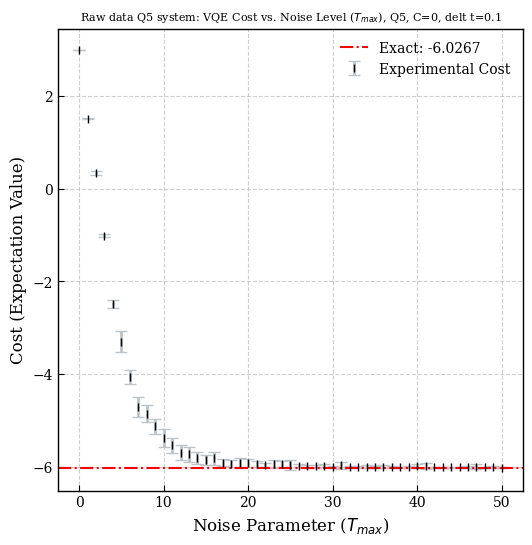

In [8]:
# Create a single clear plot
plt.figure(figsize=(6, 6))
plt.errorbar(noise_levels_c0, vqe_means_c0, yerr=vqe_stds_c0, fmt='|', color='black', 
             ecolor='#bdc3c7', elinewidth=2, capsize=4, markersize=6, 
             label='Experimental Cost')

plt.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
# Aesthetic improvements
plt.title("Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$), Q5, C=0, delt t=0.1", fontsize=8)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot (if in a script) or show (if in a notebook)
#plt.savefig('raw_data_trend.png')
plt.show()

---

In [9]:
"""
Extract experimental data.

Definitions:
    t        → T_max (noise scaling parameter)
    y        → measured energy
    sigma    → standard deviation (optional)
"""

t = noise_levels_c0          # T_max
y = vqe_means_c0
STD_WT = 0.01
sigma = STD_WT + vqe_stds_c0

print(f"Loaded {len(t)} data points")
print(f"T_max range: [{t.min()}, {t.max()}]")

Loaded 51 data points
T_max range: [0, 50]


In [10]:
"""
Fixed Hill exponents to test.
"""

n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Initial guess for fitted parameters:
#   p0[0] = ZNE → zero-noise extrapolated energy
#   p0[1] = A0  → amplitude = f(0) - ZNE (must be positive)
#   p0[2] = T0  → characteristic noise scale
#   p0 = [ZNE_guess, A0_guess, T0_guess]
p0 = [-5.0, 10.0, 30.0]

bounds = (
    [-10.0, 0.0, 10.0],
    [-1.0, 20.0, 50.0],
)

In [11]:
"""
Store *all* fitting results for later comparison.

Structure:
    results[n] = {
        "params": {ZNE, A, T0},
        "cov": covariance matrix,
        "y_fit": fitted curve,
        "residuals": data - fit,
        "chi2": chi-square,
        "chi2_red": reduced chi-square
    }
"""

fit_results = {}

In [12]:
for n in n_values:

    result_fit_hill_noiseless = fit_hill_noiseless(
        t=t,
        y=y,
        sigma=sigma,
        n=n,
        p0=p0,
        bounds=bounds,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
        max_nfev=5000,
    )

    ZNE, A0, T0 = result_fit_hill_noiseless["output"]["popt"]
    pcov = result_fit_hill_noiseless["output"]["pcov"]

    y_fit = hill(t=t, ZNE=ZNE, A=A0, T0=T0, n=n)
    residuals = y - y_fit

    LS = np.sum((residuals / sigma) ** 2)
    dof = len(y) - 3
    LS_red = LS / dof

    fit_results[n] = {
        "initial_guess": {
            "ZNE0": p0[0],
            "A0_0": p0[1],
            "T0_0": p0[2],
        },
        "params": {
            "ZNE": ZNE,
            "A0": A0,
            "T0": T0,
        },
        "cov": pcov,
        "y_fit": y_fit,
        "residuals": residuals,
        "LS": LS,
        "LS_red": LS_red,
        "dof": dof,
    }


In [13]:
"""
Summary table for noiseless Hill fitting.

Columns:
    ZNE_init, A0_init, T0_init → initial guesses (p0)
    ZNE_fit,  A0_fit,  T0_fit  → fitted parameters
    LS_red                  → reduced chi-square
"""

print(
    f"{'n':>2} | "
    f"{'ZNE_init':>9} | {'A0_init':>9} | {'T0_init':>8} || "
    f"{'ZNE_fit':>9} | {'A0_fit':>9} | {'T0_fit':>8} | "
    f"{'LS':>8}"
)
print("-" * 96)

for n, res in fit_results.items():
    ig = res["initial_guess"]
    p  = res["params"]

    print(
        f"{n:2d} | "
        f"{ig['ZNE0']:9.3f} | "
        f"{ig['A0_0']:9.3f} | "
        f"{ig['T0_0']:8.2f} || "
        f"{p['ZNE']:9.4f} | "
        f"{p['A0']:9.4f} | "
        f"{p['T0']:8.2f} | "
        f"{res['LS']:8.3f}"
    )

 n |  ZNE_init |   A0_init |  T0_init ||   ZNE_fit |    A0_fit |   T0_fit |       LS
------------------------------------------------------------------------------------------------
 1 |    -5.000 |    10.000 |    30.00 ||   -8.3363 |   11.1214 |    10.00 | 9291.696
 2 |    -5.000 |    10.000 |    30.00 ||   -6.6517 |    9.1598 |    10.00 | 17300.049
 3 |    -5.000 |    10.000 |    30.00 ||   -6.2117 |    8.6702 |    10.00 | 19066.577
 4 |    -5.000 |    10.000 |    30.00 ||   -6.0816 |    8.5269 |    10.00 | 19689.406
 5 |    -5.000 |    10.000 |    30.00 ||   -6.0383 |    8.4781 |    10.00 | 20053.469
 6 |    -5.000 |    10.000 |    30.00 ||   -6.0217 |    8.4583 |    10.00 | 20316.162
 7 |    -5.000 |    10.000 |    30.00 ||   -6.0143 |    8.4487 |    10.00 | 20524.295
 8 |    -5.000 |    10.000 |    30.00 ||   -6.0104 |    8.4430 |    10.00 | 20697.100
 9 |    -5.000 |    10.000 |    30.00 ||   -6.0080 |    8.4392 |    10.00 | 20844.366
10 |    -5.000 |    10.000 |    30.00 ||   -6

---

### $T_{max}$ range [0, 30]

In [14]:
"""
Extract experimental data.

Definitions:
    t        → T_max (noise scaling parameter)
    y        → measured energy
    sigma    → standard deviation (optional)
"""

t = noise_levels_c0[:30]          # T_max
y = vqe_means_c0[:30]
std_wt = 0.01
sigma = std_wt + vqe_stds_c0[:30]

print(f"Loaded {len(t)} data points")
print(f"T_max range: [{t.min()}, {t.max()}]")

"""
Fixed Hill exponents to test.
"""

n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Initial guess for fitted parameters:
#   p0[0] = ZNE → zero-noise extrapolated energy
#   p0[1] = A0  → amplitude = f(0) - ZNE (must be positive)
#   p0[2] = T0  → characteristic noise scale
#   p0 = [ZNE_guess, A0_guess, T0_guess]
p0 = [-5.0, 10.0, 30.0]

bounds = (
    [-10.0, 0.0, 10.0],
    [-1.0, 20.0, 50.0],
)


Loaded 30 data points
T_max range: [0, 29]


In [15]:
for n in n_values:

    result_fit_hill_noiseless_across_n = fit_hill_noiseless(
        t=t,
        y=y,
        sigma=sigma,
        n=n,
        p0=p0,
        bounds=bounds,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
        max_nfev=5000,
    )

    ZNE, A0, T0 = result_fit_hill_noiseless_across_n["output"]["popt"]
    pcov = result_fit_hill_noiseless_across_n["output"]["pcov"]
    
    y_fit = hill(t=t, ZNE=ZNE, A=A0, T0=T0, n=n)
    residuals = y - y_fit

    LS = np.sum((residuals / sigma) ** 2)
    dof = len(y) - 3
    LS_red = LS / dof

    fit_results[n] = {
        "initial_guess": {
            "ZNE0": p0[0],
            "A0_0": p0[1],
            "T0_0": p0[2],
        },
        "params": {
            "ZNE": ZNE,
            "A0": A0,
            "T0": T0,
        },
        "cov": pcov,
        "y_fit": y_fit,
        "residuals": residuals,
        "LS": LS,
        "LS_red": LS_red,
        "dof": dof,
    }


In [16]:
"""
Summary table for noiseless Hill fitting.

Columns:
    ZNE_init, A0_init, T0_init → initial guesses (p0)
    ZNE_fit,  A0_fit,  T0_fit  → fitted parameters
    LS_red                  → reduced chi-square
"""
print(f"T_max range [0, 30]: {t}")
print(
    f"{'n':>2} | "
    f"{'ZNE_init':>9} | {'A0_init':>9} | {'T0_init':>8} || "
    f"{'ZNE_fit':>9} | {'A0_fit':>9} | {'T0_fit':>8} | "
    f"{'LS':>8}"
)
print("-" * 96)

for n, res in fit_results.items():
    ig = res["initial_guess"]
    p  = res["params"]
    
    print(
        f"{n:2d} | "
        f"{ig['ZNE0']:9.3f} | "
        f"{ig['A0_0']:9.3f} | "
        f"{ig['T0_0']:8.2f} || "
        f"{p['ZNE']:9.4f} | "
        f"{p['A0']:9.4f} | "
        f"{p['T0']:8.2f} | "
        f"{res['LS']:8.3f}"
    )

T_max range [0, 30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
 n |  ZNE_init |   A0_init |  T0_init ||   ZNE_fit |    A0_fit |   T0_fit |       LS
------------------------------------------------------------------------------------------------
 1 |    -5.000 |    10.000 |    30.00 ||   -9.8628 |   12.7456 |    10.00 | 2877.586
 2 |    -5.000 |    10.000 |    30.00 ||   -7.6584 |   10.2061 |    10.00 | 13745.276
 3 |    -5.000 |    10.000 |    30.00 ||   -6.7601 |    9.2310 |    10.00 | 17909.370
 4 |    -5.000 |    10.000 |    30.00 ||   -6.3824 |    8.8317 |    10.00 | 19329.262
 5 |    -5.000 |    10.000 |    30.00 ||   -6.2100 |    8.6513 |    10.00 | 19932.931
 6 |    -5.000 |    10.000 |    30.00 ||   -6.1244 |    8.5616 |    10.00 | 20271.354
 7 |    -5.000 |    10.000 |    30.00 ||   -6.0780 |    8.5126 |    10.00 | 20505.756
 8 |    -5.000 |    10.000 |    30.00 ||   -6.0505 |    8.4833 |    10.00 | 20688.575
 9 |    -5.000 | 

---

In [17]:
"""
Extract experimental data.

Definitions:
    t        → T_max (noise scaling parameter)
    y        → measured energy
    sigma    → standard deviation (optional)
"""

t = noise_levels_c0[:30]          # T_max
y = vqe_means_c0[:30]
std_wt = 0.01
sigma = std_wt + vqe_stds_c0[:30]

"""
Fixed Hill exponents to test.
"""

n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Initial guess for fitted parameters:
#   p0[0] = ZNE → zero-noise extrapolated energy
#   p0[1] = A0  → amplitude = f(0) - ZNE (must be positive)
#   p0[2] = T0  → characteristic noise scale
#   p0 = [ZNE_guess, A0_guess, T0_guess]
p0 = [-5.0, 10.0, 8]

bounds = (
    [-10.0, 0.0, 0],
    [-1.0, 20.0, 50.0],
)

for n in n_values:

    result_fit_hill_noiseless_across_n = fit_hill_noiseless(
        t=t,
        y=y,
        sigma=sigma,
        n=n,
        p0=p0,
        bounds=bounds,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
        max_nfev=5000,
    )

    ZNE, A0, T0 = result_fit_hill_noiseless_across_n["output"]["popt"]
    pcov = result_fit_hill_noiseless_across_n["output"]["pcov"]

    y_fit = hill(t=t, ZNE=ZNE, A=A0, T0=T0, n=n)
    residuals = y - y_fit

    LS = np.sum((residuals / sigma) ** 2)
    dof = len(y) - 3
    LS_red = LS / dof

    fit_results[n] = {
        "n": n,
        "initial_guess": {
            "ZNE0": p0[0],
            "A0_0": p0[1],
            "T0_0": p0[2],
        },
        "params": {
            "ZNE": ZNE,
            "A0": A0,
            "T0": T0,
        },
        "cov": pcov,
        "y_fit": y_fit,
        "residuals": residuals,
        "LS": LS,
        "LS_red": LS_red,
        "dof": dof,
    }
"""
Summary table for noiseless Hill fitting.

Columns:
    ZNE_init, A0_init, T0_init → initial guesses (p0)
    ZNE_fit,  A0_fit,  T0_fit  → fitted parameters
    LS_red                  → reduced chi-square
"""
print(f"T_max range [0, 30]: {t}\n\n")
print(
    f"{'n':>2} | "
    f"{'ZNE_init':>9} | {'A0_init':>9} | {'T0_init':>8} || "
    f"{'ZNE_fit':>9} | {'A0_fit':>9} | {'T0_fit':>8} | "
    f"{'LS':>8}"
)
print("-" * 96)

for n, res in fit_results.items():
    ig = res["initial_guess"]
    p  = res["params"]
    
    print(
        f"{n:2d} | "
        f"{ig['ZNE0']:9.3f} | "
        f"{ig['A0_0']:9.3f} | "
        f"{ig['T0_0']:8.2f} || "
        f"{p['ZNE']:9.4f} | "
        f"{p['A0']:9.4f} | "
        f"{p['T0']:8.2f} | "
        f"{res['LS']:8.3f}"
    )

T_max range [0, 30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]


 n |  ZNE_init |   A0_init |  T0_init ||   ZNE_fit |    A0_fit |   T0_fit |       LS
------------------------------------------------------------------------------------------------
 1 |    -5.000 |    10.000 |     8.00 ||   -7.9469 |   10.9786 |     5.20 |  862.552
 2 |    -5.000 |    10.000 |     8.00 ||   -6.0887 |    9.0217 |     3.04 |  709.796
 3 |    -5.000 |    10.000 |     8.00 ||   -5.9194 |    8.7522 |     2.98 | 2475.397
 4 |    -5.000 |    10.000 |     8.00 ||   -5.8848 |    8.6586 |     3.03 | 3855.062
 5 |    -5.000 |    10.000 |     8.00 ||   -5.8700 |    8.6109 |     3.06 | 4817.718
 6 |    -5.000 |    10.000 |     8.00 ||   -5.8606 |    8.5808 |     3.08 | 5527.613
 7 |    -5.000 |    10.000 |     8.00 ||   -5.8525 |    8.5591 |     3.10 | 6061.326
 8 |    -5.000 |    10.000 |     8.00 ||   -5.8446 |    8.5424 |     3.10 | 6463.625
 9 |    -5.000 |    10

---

In [18]:
BEST_n  = 2
BEST_T0 = 3.04
BEST_A0 = 9.0217
ZNE_c0_best = -6.0887
E_mix   = 0.0   # Tr(H_Ising) = 0

lsf_record_c0 = {
    "model": "ZNE + A/(1+(t/T0)^n)",
    "lsf": fit_results,
    "bests": {
        "n": BEST_n,
        "A": BEST_A0,
        "T0": BEST_T0,
        "ZNE": ZNE_c0_best,
    }
}

---

####  Noisy LSF with $C$=0.01

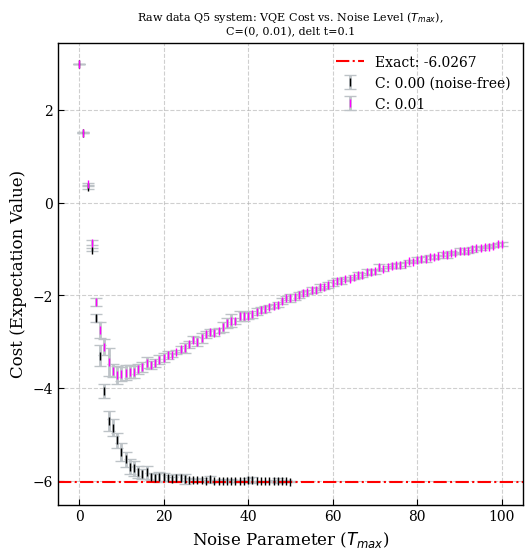

In [19]:
# Extracting components
vqe_means_c0_01 = data_records["c0.01"]["processed"]["vqe_means"]
vqe_stds_c0_01 = data_records["c0.01"]["processed"]["vqe_stds"]
noise_levels_c0_01 = data_records["c0.01"]["processed"]["t_max"]
# Create a single clear plot
plt.figure(figsize=(6, 6))
plt.errorbar(noise_levels_c0, vqe_means_c0, yerr=vqe_stds_c0, fmt='|', color='black', 
             ecolor='#bdc3c7', elinewidth=2, capsize=4, markersize=6, 
             label='C: 0.00 (noise-free)')
plt.errorbar(noise_levels_c0_01, vqe_means_c0_01, yerr=vqe_stds_c0_01, fmt='|', color='magenta', 
             ecolor='#bdc3c7', elinewidth=2, capsize=4, markersize=6, 
             label='C: 0.01')
plt.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
# Aesthetic improvements
plt.title("Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$),\nC=(0, 0.01), delt t=0.1", fontsize=8)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot (if in a script) or show (if in a notebook)
# plt.savefig('raw_data_trend.png')
plt.show()

In [20]:
# =========================
# Data selection (large-t window)
# =========================
mask = 51
rec = data_records["c0.01"]

t = rec["processed"]["t_max"][-mask:]
y = rec["processed"]["vqe_means"][-mask:]
sigma = rec["processed"]["vqe_stds"][-mask:]

# =========================
# Initial guesses and bounds
# Model: f(t) = B * exp(-gamma * t)
# Parameter order: [gamma, B]
# =========================
B_guess = BEST_A0 + ZNE_c0_best
p0 = [
    0.05,      # gamma: slow decay at large-t
    B_guess,      # B: first point in large-t window
]

bounds = (
    [1e-6, -np.inf],   # gamma > 0, B free
    [1.0,   np.inf],   # gamma not too large (stiff), B free
)

# =========================
# Call the fitter
# =========================
result_fit_gamma_largeT = fit_gamma_largeT(
    t=t,
    y=y,
    sigma=sigma,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    verbose=2,
)

# =========================
# Extract results
# =========================
popt = result_fit_gamma_largeT["output"]["popt"]
pcov = result_fit_gamma_largeT["output"]["pcov"]

gamma_fit, B_fit = popt

# =========================
# Clean summary table
# =========================
print("\nLarge-T Exponential Fit: f(t) = B · exp(−γ t)\n")
print(f"{'param':>6} | {'initial':>12} | {'fitted':>12}")
print("-" * 36)
print(f"{'gamma':>6} | {p0[0]:12.4e} | {gamma_fit:12.4e}")
print(f"{'B':>6} | {p0[1]:12.4e} | {B_fit:12.4e}")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.0635e+04                                    2.28e+05    
       1              2         2.7113e+04      3.52e+03       2.93e+00       2.81e-02    
       2              3         2.7113e+04      1.67e-04       7.30e-01       2.50e-04    
       3              4         2.7113e+04      5.29e-03       1.11e-01       7.38e-02    
       4              5         2.6909e+04      2.04e+02       1.93e-01       9.35e+02    
       5              6         1.7537e+03      2.52e+04       6.91e-01       5.37e+03    
       6              7         7.6944e+02      9.84e+02       4.20e-01       6.66e+04    
       7              9         5.1802e+02      2.51e+02       3.67e-01       1.00e+03    
       8             10         2.3453e+02      2.83e+02       7.32e-01       1.43e+03    
       9             11         6.8052e+01      1.66e+02       7.38e-01       9.30e+02    

In [21]:
# =========================
# Data selection (large-t window)
# =========================
mask = 6
rec = data_records["c0.01"]

t = rec["processed"]["t_max"][:mask]
y = rec["processed"]["vqe_means"][:mask]
sigma = rec["processed"]["vqe_stds"][:mask]

# Initial guess and bounds
p0 = [
    -5, # ZNE from noise less c=0
    10,     # A from noiseless c=0
    8,     # T0 from noiseless c=0
]

bounds = (
    [-10.0,   0.0,  0], # lower [ ZNE, A, T0 ]
    [ 0., 200.0, 10],   # upper [ ZNE, A, T0 ]
)

result_fit_in_smallT = fit_smallT_ZNE(
    t=t,
    y=y,
    sigma=sigma,
    n=BEST_n,          # fixed exponent BEST_n=2
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    verbose=2,
)

# =====================================================
# Clean parameter summary (initial vs fitted)
# =====================================================

popt = result_fit_in_smallT["output"]["popt"]
pcov = result_fit_in_smallT["output"]["pcov"]

ZNE_fit, A_fit, T0_fit = popt

print("\nSmall-T Hill Fit:  f(t) = ZNE + A / (1 + (t/T0)^n) with n=2\n")
print(f"{'param':>6} | {'initial':>12} | {'fitted':>12}")
print("-" * 36)
print(f"{'ZNE':>6} | {p0[0]:12.4f} | {ZNE_fit:12.4f}")
print(f"{'A':>6} | {p0[1]:12.4f} | {A_fit:12.4f}")
print(f"{'T0':>6} | {p0[2]:12.4f} | {T0_fit:12.4f}")

print(
    f"\nRelative uncertainties:\n"
    f"  ZNE : {np.sqrt(pcov[0,0]) / abs(ZNE_fit):.2e}\n"
    f"  A   : {np.sqrt(pcov[1,1]) / abs(A_fit):.2e}\n"
    f"  T0  : {np.sqrt(pcov[2,2]) / T0_fit:.2e}"
)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.3506e+14                                    4.35e+15    
       1              2         6.0216e+12      4.29e+14       3.74e+00       4.52e+14    
       2              3         1.8372e+09      6.02e+12       1.82e+00       7.75e+12    
       3              4         1.2547e+03      1.84e+09       2.86e-01       2.45e+09    
       4              5         1.0653e+03      1.89e+02       2.72e-02       1.29e+03    
       5              6         2.9221e+02      7.73e+02       3.76e+00       4.47e+03    
       6              7         1.7771e+02      1.15e+02       6.31e-01       3.10e+02    
       7              8         1.4298e+02      3.47e+01       6.94e-01       3.30e+02    
       8              9         1.4163e+02      1.35e+00       1.22e-01       1.68e+01    
       9             10         1.4161e+02      2.15e-02       1.73e-02       1.53e+00    

In [22]:
# =========================
# Data selection (large-t window)
# =========================
mask = 101
rec = data_records["c0.01"]

t = rec["processed"]["t_max"][:mask]
y = rec["processed"]["vqe_means"][:mask]
sigma = rec["processed"]["vqe_stds"][:mask]

# Initial guess and bounds
p0 = [
    1.6758e-02, # gamma from large-t fit
    -2.0177814739005315, # ZNE from noisy fit
    5.0178,     # A from noisy fit
    1.5548,     # T0 from noisy fit
]

bounds = (
    [1e-6, -10.0,   0.0,  0], # lower [ gama, ZNE, A, T0 ]
    [1, 0., 200.0, 10],   # upper [ gama, ZNE, A, T0 ]
)
result_global = fit_f_noisy(
    t=t,
    y=y,
    sigma=sigma,
    n=BEST_n,          # fixed exponent BEST_n=2
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    verbose=2,
)

# =====================================================
# Clean parameter summary (initial vs fitted)
# =====================================================


popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

gamma_fit, ZNE_fit, A_fit, T0_fit = popt

print(
    "\nEntire noisy Hill Fit:\n"
    "f_noisy(t) = exp(-gamma * t) * [ ZNE + A / (1 + (t / T0)**n) ]\n"
    f"(n = {BEST_n})\n"
)

print(f"{'param':>6} | {'initial':>12} | {'fitted':>12}")
print("-" * 38)
print(f"{'gamma':>6} | {p0[0]:12.4e} | {gamma_fit:12.4e}")
print(f"{'ZNE':>6} | {p0[1]:12.4f} | {ZNE_fit:12.4f}")
print(f"{'A':>6} | {p0[2]:12.4f} | {A_fit:12.4f}")
print(f"{'T0':>6} | {p0[3]:12.4f} | {T0_fit:12.4f}")

print("\nRelative uncertainties:")
print(f"  gamma : {np.sqrt(pcov[0,0]) / abs(gamma_fit):.2e}")
print(f"  ZNE   : {np.sqrt(pcov[1,1]) / abs(ZNE_fit):.2e}")
print(f"  A     : {np.sqrt(pcov[2,2]) / abs(A_fit):.2e}")
print(f"  T0    : {np.sqrt(pcov[3,3]) / abs(T0_fit):.2e}")


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.6406e+04                                    3.20e+10    
       1              2         7.0887e+03      4.93e+04       9.74e-03       8.47e+04    
       2              3         2.4777e+03      4.61e+03       1.26e+00       3.58e+04    
       3              4         8.5830e+02      1.62e+03       1.67e+00       1.13e+04    
       4              5         5.8757e+02      2.71e+02       4.76e-01       8.13e+02    
       5              6         5.7793e+02      9.64e+00       1.76e-01       2.36e+02    
       6              7         5.7786e+02      6.67e-02       9.54e-03       2.66e+01    
       7              8         5.7786e+02      5.40e-04       7.97e-04       2.63e+01    
       8              9         5.7786e+02      4.98e-06       7.29e-05       1.59e+01    
       9             10         5.7786e+02      4.59e-08       7.06e-06       1.14e+01    

In [23]:
# =========================
# Data selection (large-t window)
# =========================
mask = 51
rec = data_records["c0.01"]

t = rec["processed"]["t_max"][:mask]
y = rec["processed"]["vqe_means"][:mask]
sigma = rec["processed"]["vqe_stds"][:mask]

# Initial guess and bounds
p0 = [
    1.6758e-02, # gamma from large-t fit
    -2.0177814739005315, # ZNE from noisy fit
    5.0178,     # A from noisy fit
    1.5548,     # T0 from noisy fit
]

bounds = (
    [1e-6, -10.0,   0.0,  0], # lower [ gama, ZNE, A, T0 ]
    [1, 0., 200.0, 10],   # upper [ gama, ZNE, A, T0 ]
)
result_global = fit_f_noisy(
    t=t,
    y=y,
    sigma=sigma,
    n=BEST_n,          # fixed exponent BEST_n=2
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    verbose=2,
)

# =====================================================
# Clean parameter summary (initial vs fitted)
# =====================================================


popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

gamma_fit, ZNE_fit, A_fit, T0_fit = popt

print(
    "\nEntire noisy Hill Fit:\n"
    "f_noisy(t) = exp(-gamma * t) * [ ZNE + A / (1 + (t / T0)**n) ]\n"
    f"(n = {BEST_n})\n"
    f"T_max: {t}"
)

print(f"{'param':>6} | {'initial':>12} | {'fitted':>12}")
print("-" * 38)
print(f"{'gamma':>6} | {p0[0]:12.4e} | {gamma_fit:12.4e}")
print(f"{'ZNE':>6} | {p0[1]:12.4f} | {ZNE_fit:12.4f}")
print(f"{'A':>6} | {p0[2]:12.4f} | {A_fit:12.4f}")
print(f"{'T0':>6} | {p0[3]:12.4f} | {T0_fit:12.4f}")

print("\nRelative uncertainties:")
print(f"  gamma : {np.sqrt(pcov[0,0]) / abs(gamma_fit):.2e}")
print(f"  ZNE   : {np.sqrt(pcov[1,1]) / abs(ZNE_fit):.2e}")
print(f"  A     : {np.sqrt(pcov[2,2]) / abs(A_fit):.2e}")
print(f"  T0    : {np.sqrt(pcov[3,3]) / abs(T0_fit):.2e}")


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.7488e+04                                    3.20e+10    
       1              2         5.1571e+03      4.23e+04       1.23e-02       7.53e+04    
       2              3         1.0320e+03      4.13e+03       1.31e+00       5.29e+04    
       3              4         6.8296e+02      3.49e+02       6.97e-01       1.92e+04    
       4              5         5.3392e+02      1.49e+02       8.93e-01       1.58e+03    
       5              6         5.2454e+02      9.38e+00       1.31e-01       1.76e+02    
       6              7         5.2439e+02      1.45e-01       3.15e-02       4.54e+01    
       7              8         5.2439e+02      1.38e-03       1.42e-03       4.06e+00    
       8              9         5.2439e+02      1.56e-05       2.40e-04       1.95e+01    
       9             10         5.2439e+02      1.82e-07       2.17e-05       1.08e+01    

In [24]:
lsf_fit_gamma_largeT = {
    "name": "fit_gamma_largeT",
    "model": "exp(-gamma t) * B",
    "result": result_fit_gamma_largeT,
}

lsf_fit_in_smallT = {
    "name": "fit_in_smallT",
    "model": "ZNE + A / (1 + (t/T0)^n)",
    "result": result_fit_in_smallT,
}

lsf_fit_global = {
    "name": "fit_global",
    "model": "exp(-gamma t) * (ZNE + A / (1 + (t/T0)^n))",
    "result": result_global,
}
gamma_noisy_opt = lsf_fit_global["result"]["output"]["popt"][0]
ZNE_noisy_opt = lsf_fit_global["result"]["output"]["popt"][1]
A_noisy_opt = lsf_fit_global["result"]["output"]["popt"][2]
T0_noisy_opt = lsf_fit_global["result"]["output"]["popt"][3]

print("\nFinal optimized parameters from global fit:")
print(f"  gamma: {gamma_noisy_opt:.6e}")
print(f"  ZNE  : {ZNE_noisy_opt:.6f}")
print(f"  A    : {A_noisy_opt:.6f}")
print(f"  T0   : {T0_noisy_opt:.6f}")


Final optimized parameters from global fit:
  gamma: 1.283032e-02
  ZNE  : -4.157016
  A    : 7.157016
  T0   : 2.051890


In [25]:
# Smooth t-grid for plotting the fit
t_fit = np.linspace(
    min(noise_levels_c0_01),
    max(noise_levels_c0_01),
    400
)

# Model definition (n fixed)
def f_noisy(t, gamma, ZNE, A, T0, n=2):
    return np.exp(-gamma * t) * (ZNE + A / (1.0 + (t / T0) ** n))

y_fit = f_noisy(
    t_fit,
    gamma_noisy_opt,
    ZNE_noisy_opt,
    A_noisy_opt,
    T0_noisy_opt,
    n=2,
)


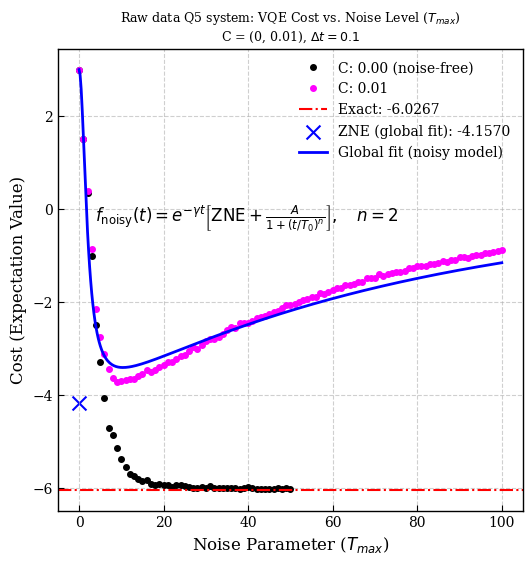

In [26]:
# =========================
# Create plot
# =========================
plt.figure(figsize=(6, 6))

# Noise-free (C = 0.00) — mean only
plt.plot(
    noise_levels_c0,
    vqe_means_c0,
    linestyle="none",
    marker=".",
    color="black",
    markersize=8,
    label="C: 0.00 (noise-free)",
)

# Noisy (C = 0.01) — mean only
plt.plot(
    noise_levels_c0_01,
    vqe_means_c0_01,
    linestyle="none",
    marker=".",
    color="magenta",
    markersize=8,
    label="C: 0.01",
)

# Exact solution
plt.axhline(
    y=EXACT_SOLUTION,
    color="red",
    linestyle="-.",
    label=f"Exact: {EXACT_SOLUTION:.4f}",
)

# ZNE point
plt.scatter(
    0,
    ZNE_noisy_opt,
    color="blue",
    marker="x",
    s=100,
    label=f"ZNE (global fit): {ZNE_noisy_opt:.4f}",
)

# Global fitted curve
plt.plot(
    t_fit,
    y_fit,
    color="blue",
    linewidth=2,
    label="Global fit (noisy model)",
)

# =========================
# Equation annotation
# =========================
eq_text = (
    rf"$f_{{\mathrm{{noisy}}}}(t)"
    rf"= e^{{-\gamma t}}\left["
    rf"\mathrm{{ZNE}} + \frac{{A}}{{1 + (t/T_0)^n}}"
    rf"\right],\quad n={BEST_n}$"
)

plt.text(
    0.08,
    0.60,
    eq_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="bottom",
)

# =========================
# Aesthetics
# =========================
plt.title(
    "Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$)\n"
    "C = (0, 0.01), $\Delta t = 0.1$",
    fontsize=9,
)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()
